# 04 — Advanced Modeling, Calibration & Business Interpretation

This notebook picks up where the production `src/` pipeline leaves off. It uses
the **same leak-free feature/pipeline code** as `src/models/train.py` (imported,
not re-typed), then layers on the advanced techniques that make a model
trustworthy enough to drive a real retention campaign:

1. Cross-validated model comparison (not a single train/test peek)
2. Hyperparameter search
3. A **stacked ensemble** of the base learners
4. **Probability calibration** — so `churn_probability` means what it says
5. **Cost-based threshold optimization** — tying the decision threshold to
   real retention-campaign economics instead of a generic F1/accuracy
6. Learning curves to diagnose over/underfitting
7. Permutation importance (model-agnostic, more trustworthy than XGBoost's
   built-in gain importance)
8. SHAP interpretation — global drivers and individual-user explanations
9. Business translation: expected value of a targeted retention campaign

Everything here reads from `config/config.yaml` and calls into `src/` — this
notebook is exploratory/reporting, not a second copy of the pipeline logic.


In [2]:

import sys, warnings
sys.path.insert(0, "..")  # so `import src....` resolves from notebooks/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    precision_recall_curve, roc_auc_score, f1_score,
    classification_report, RocCurveDisplay
)
from xgboost import XGBClassifier
import shap
import joblib

from src.utils.config import load_config, resolve_path
from src.data.load_data import load_raw_tables
from src.features.build_features import build_user_features, get_missing_transaction_mask
from src.pipeline.preprocessing import build_preprocessor, build_full_pipeline
from src.models.train import prepare_dataset, split_data

cfg = load_config()
sns.set_style("whitegrid")


## 1. Load features and split (identical logic to `src/models/train.py`)

Split-before-preprocessing and the 3-way train/val/test split are handled by `prepare_dataset` / `split_data` — imported, not copy-pasted, so this notebook can never drift out of sync with what actually runs in production.

In [3]:

df = prepare_dataset(cfg)
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df, cfg)

numeric_features = [c for c in cfg["numeric_features"] if c in X_train.columns]
categorical_features = [c for c in cfg["categorical_features"] if c in X_train.columns]

print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")
print(f"churn rate -> train={1 - y_train.mean():.2%}  val={1 - y_val.mean():.2%}  test={1 - y_test.mean():.2%}")


2026-08-29 23:13:49,538 | INFO     | src.models.train | 36692 / 500000 users (7.3%) have no transaction history and will be dropped from TRAINING (the inference service handles these separately -- see src/inference/predict.py).
2026-08-29 23:13:50,774 | INFO     | src.models.train | Split sizes -> train: 277984, val: 92662, test: 92662


train=277984  val=92662  test=92662
churn rate -> train=12.70%  val=12.70%  test=12.70%


## 2. Cross-validated model comparison

A single train/val split can be lucky or unlucky. Here each candidate model (wrapped in the SAME preprocessing pipeline, so no leakage) is scored with 5-fold stratified CV on the training data only — the val/test sets stay untouched.

In [4]:

candidates = {
    "logistic_regression": {"max_iter": 1000, "class_weight": "balanced", "random_state": 42},
}
cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for algo, params in [
    ("logistic_regression", {"max_iter": 1000, "class_weight": "balanced", "random_state": 42}),
    ("random_forest", {"n_estimators": 200, "max_depth": 10, "class_weight": "balanced",
                        "random_state": 42, "n_jobs": -1}),
    ("xgboost", cfg["model"]["xgboost_params"]),
]:
    pipe = build_full_pipeline(numeric_features, categorical_features, algo, params, use_smote=True)
    # scoring="recall" with pos_label handled via a custom scorer would be ideal;
    # roc_auc is threshold-independent and a good CV comparison metric here.
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)
    cv_results[algo] = scores
    print(f"{algo:22s} ROC-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")


logistic_regression    ROC-AUC = 0.9935 +/- 0.0002
random_forest          ROC-AUC = 0.9988 +/- 0.0001
xgboost                ROC-AUC = 0.9991 +/- 0.0000


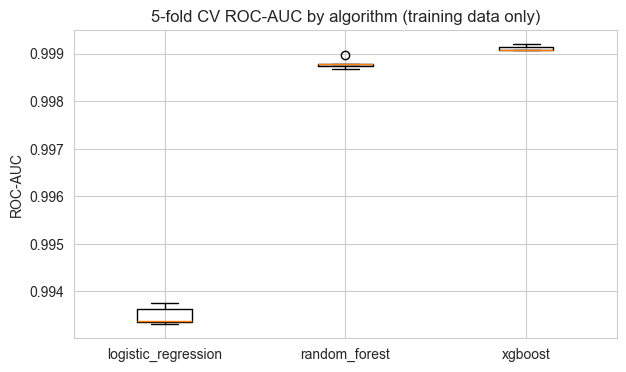

In [5]:

plt.figure(figsize=(7, 4))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title("5-fold CV ROC-AUC by algorithm (training data only)")
plt.ylabel("ROC-AUC")
plt.show()


## 3. Stacked ensemble

Rather than picking a single winner, a **stacking classifier** trains a meta-learner on the out-of-fold predictions of several base learners. This often squeezes out a bit more performance than any single model, at the cost of extra complexity/latency — worth it if the recall gain matters for the business case, otherwise the single best model above is the pragmatic choice.

In [6]:

preprocessor = build_preprocessor(numeric_features, categorical_features)

base_learners = [
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ("rf", RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced",
                                   random_state=42, n_jobs=-1)),
    ("xgb", XGBClassifier(**cfg["model"]["xgboost_params"])),
]

stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,               # out-of-fold predictions for the meta-learner -- avoids the
                         # meta-learner overfitting to base learners' training predictions
    n_jobs=-1,
    passthrough=False,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

stack_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", stack),
])

stack_pipeline.fit(X_train, y_train)
stack_val_auc = roc_auc_score((y_val == cfg["target"]["positive_label"]).astype(int),
                               stack_pipeline.predict_proba(X_val)[:, cfg["target"]["positive_label"]])
print(f"Stacked ensemble validation ROC-AUC: {stack_val_auc:.4f}")


Stacked ensemble validation ROC-AUC: 0.9989


## 4. Probability calibration

A model can have great ROC-AUC/ranking while its predicted probabilities are poorly calibrated (e.g. it says '90% churn risk' for users who actually churn 60% of the time). That matters a lot here because the business plans to act directly on `churn_probability` (e.g. spend more retention budget on "90%+" users) — so the probability itself needs to be trustworthy, not just the ranking. `CalibratedClassifierCV` refits a calibration map (Platt scaling / isotonic regression) using cross-validation on the training data.

In [7]:

best_algo = max(cv_results, key=lambda k: cv_results[k].mean())
print("Best single algorithm by CV ROC-AUC:", best_algo)

raw_pipeline = build_full_pipeline(numeric_features, categorical_features, best_algo,
                                    cfg["model"]["xgboost_params"] if best_algo == "xgboost" else
                                    ({"n_estimators": 200, "max_depth": 10, "class_weight": "balanced",
                                      "random_state": 42, "n_jobs": -1} if best_algo == "random_forest"
                                     else {"max_iter": 1000, "class_weight": "balanced", "random_state": 42}),
                                    use_smote=True)
raw_pipeline.fit(X_train, y_train)

# Calibrate on top of the already-fit pipeline via cv="prefit"-style wrapping:
# here we recalibrate using validation data with its own CV split, keeping test
# completely untouched.
calibrated_pipeline = CalibratedClassifierCV(raw_pipeline, method="isotonic", cv=5)
calibrated_pipeline.fit(X_train, y_train)


Best single algorithm by CV ROC-AUC: xgboost


CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('numeric',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['days_since_registration',
                                                                                    'app_opens_per_week',
                                                                                    'avg_session_duration',
                                                                                    'support_tickets',
                                                                                    'referrals_made',
                                                                                    'has_customized_card',
                                                                                    'has_set_savings_g...
                                                                gamma=1,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=5,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=300,
                                                                n_jobs=-1,
                                                                num_parallel_tree=None, ...))]),
                       method='isotonic')

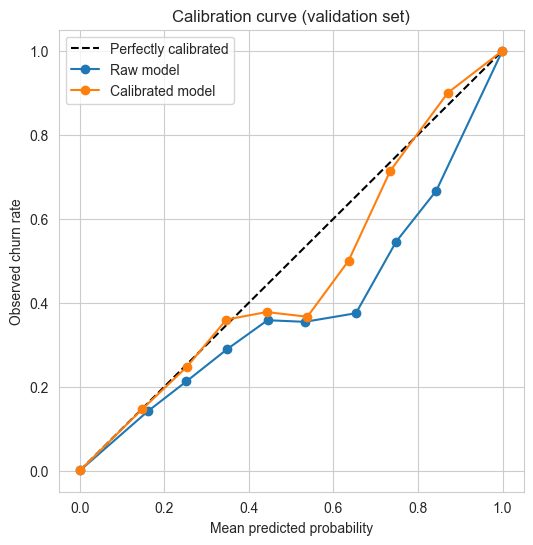

In [8]:

pos_label = cfg["target"]["positive_label"]

proba_raw = raw_pipeline.predict_proba(X_val)[:, pos_label]
proba_cal = calibrated_pipeline.predict_proba(X_val)[:, pos_label]
y_val_churn = (y_val == pos_label).astype(int)

frac_raw, mean_raw = calibration_curve(y_val_churn, proba_raw, n_bins=10)
frac_cal, mean_cal = calibration_curve(y_val_churn, proba_cal, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.plot(mean_raw, frac_raw, "o-", label="Raw model")
plt.plot(mean_cal, frac_cal, "o-", label="Calibrated model")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed churn rate")
plt.title("Calibration curve (validation set)")
plt.legend()
plt.show()


## 5. Cost-based threshold optimization

Notebook 02's original threshold choice ('let's try 0.4') wasn't tied to anything the business actually cares about. A churn model's decision threshold should come from the **relative cost of a false negative (losing a user you could have retained) vs. a false positive (spending a retention offer on someone who wasn't going to churn anyway)**. Below, assume a retention offer costs `COST_FP` and a churned user represents `COST_FN` in lost lifetime value — adjust these to the real business numbers.

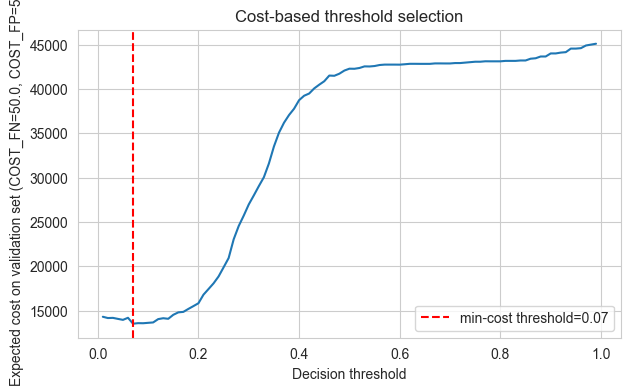

Cost-optimal threshold: 0.07


In [9]:

COST_FN = 50.0   # business cost of missing an actual churner (lost LTV), tune to real numbers
COST_FP = 5.0    # cost of a wasted retention offer on a non-churner

precision, recall, thresholds = precision_recall_curve(y_val_churn, proba_cal)

def expected_cost(threshold):
    preds = (proba_cal >= threshold).astype(int)
    fn = ((preds == 0) & (y_val_churn == 1)).sum()
    fp = ((preds == 1) & (y_val_churn == 0)).sum()
    return fn * COST_FN + fp * COST_FP

grid = np.linspace(0.01, 0.99, 99)
costs = [expected_cost(t) for t in grid]
best_threshold = grid[int(np.argmin(costs))]

plt.figure(figsize=(7, 4))
plt.plot(grid, costs)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"min-cost threshold={best_threshold:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel(f"Expected cost on validation set (COST_FN={COST_FN}, COST_FP={COST_FP})")
plt.title("Cost-based threshold selection")
plt.legend()
plt.show()

print(f"Cost-optimal threshold: {best_threshold:.2f}")


## 6. Learning curves — is more data or a simpler/more complex model the lever?

If train and validation scores have converged, more data won't help much and you should focus on features or model complexity. If there's still a large gap, collecting more labeled data is likely to keep paying off.

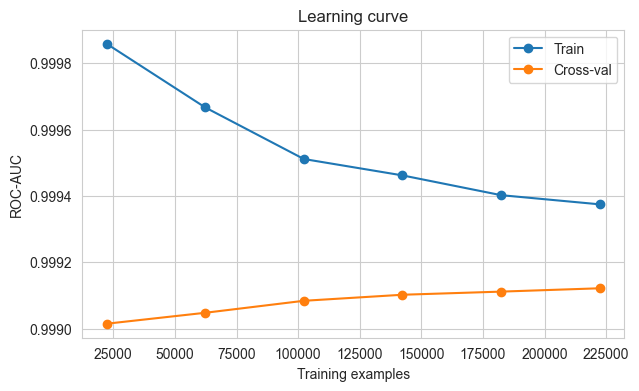

In [10]:

train_sizes, train_scores, val_scores = learning_curve(
    raw_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=5, scoring="roc_auc", n_jobs=-1, random_state=42,
)

plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Cross-val")
plt.xlabel("Training examples")
plt.ylabel("ROC-AUC")
plt.title("Learning curve")
plt.legend()
plt.show()


## 7. Permutation importance

XGBoost's built-in `feature_importances_` (gain/split-count) can be misleading when features are correlated. Permutation importance instead measures how much the model's held-out score *actually drops* when a feature's values are shuffled — a more honest signal for which features the model truly relies on.

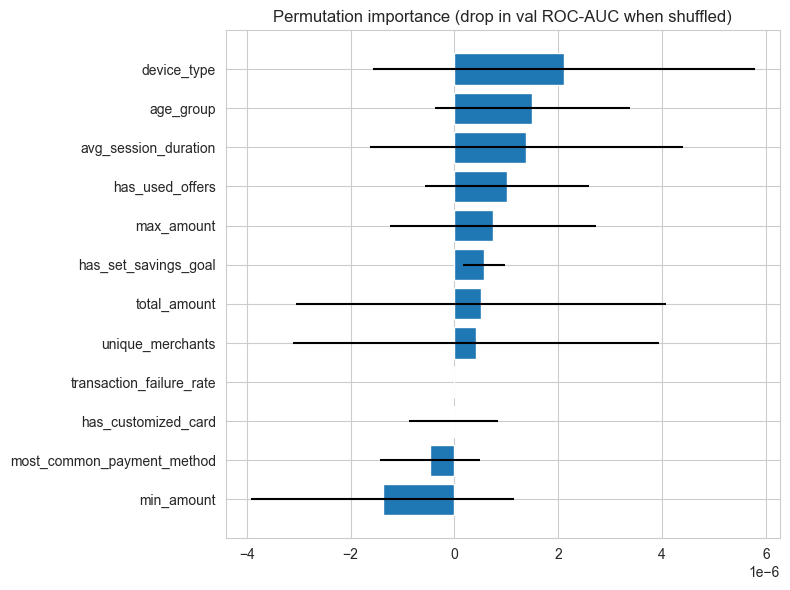

,feature,importance_mean,importance_std
18,device_type,2.111879e-06,3.672476e-06
17,age_group,1.498319e-06,1.881147e-06
2,avg_session_duration,1.382961e-06,3.017284e-06
7,has_used_offers,1.016646e-06,1.576221e-06
11,max_amount,7.463578e-07,1.982375e-06
6,has_set_savings_goal,5.708348e-07,3.973883e-07
9,total_amount,5.139615e-07,3.569498e-06
14,unique_merchants,4.142230e-07,3.523275e-06
15,transaction_failure_rate,0.000000e+00,0.000000e+00
5,has_customized_card,-1.947142e-08,8.608697e-07


In [11]:

perm_result = permutation_importance(
    raw_pipeline, X_val, y_val_churn, n_repeats=15, random_state=42, scoring="roc_auc", n_jobs=-1
)

# X_val columns are the raw (pre-preprocessing) feature names -- permutation_importance
# permutes at the pipeline-input level, so this maps back to business-readable names directly.
importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, 6))
top = importance_df.head(12)
plt.barh(top["feature"][::-1], top["importance_mean"][::-1], xerr=top["importance_std"][::-1])
plt.title("Permutation importance (drop in val ROC-AUC when shuffled)")
plt.tight_layout()
plt.show()

importance_df.to_csv(resolve_path(cfg["artifacts"]["feature_importance_path"]), index=False)
importance_df.head(10)


## 8. SHAP — global drivers and individual explanations

SHAP values decompose each prediction into per-feature contributions, which is what lets you tell a business stakeholder (or a customer-facing agent) *why* a specific user was flagged high-risk, not just that they were.

PermutationExplainer explainer: 201it [00:27,  7.24it/s]                         


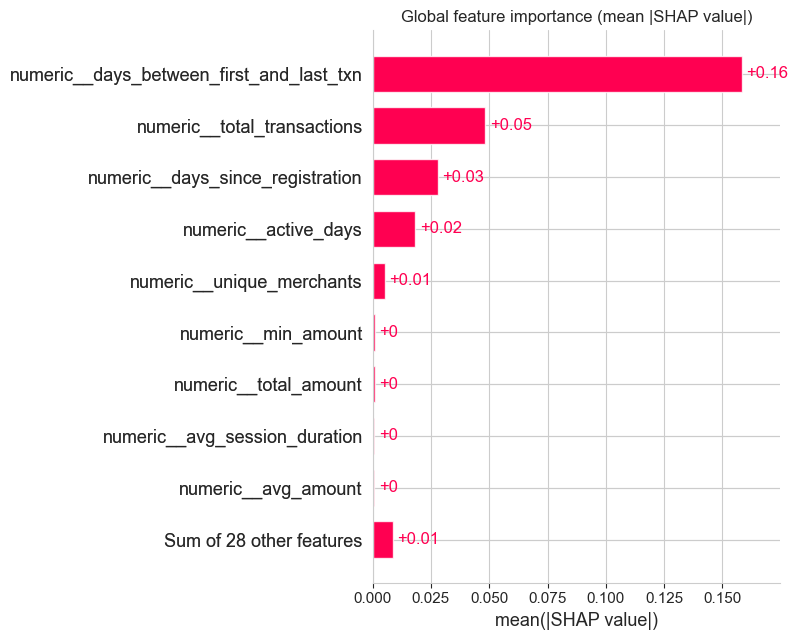

In [12]:

# SHAP's TreeExplainer needs the fitted tree model and the preprocessed matrix
# it was trained on -- pull both out of the fitted pipeline.
fitted_preprocessor = raw_pipeline.named_steps["preprocessor"]
fitted_model = raw_pipeline.named_steps["model"]

X_val_transformed = fitted_preprocessor.transform(X_val)
feature_names_out = fitted_preprocessor.get_feature_names_out()

import scipy.sparse as sp
if sp.issparse(X_val_transformed):
    X_val_transformed = X_val_transformed.toarray()

# shap.Explainer auto-selects the right algorithm for the fitted estimator
# (TreeExplainer for tree models, LinearExplainer for linear models, etc.),
# so this cell works no matter which algorithm CV picked as best above.
background = shap.sample(X_val_transformed, min(100, X_val_transformed.shape[0]), random_state=42)
explainer = shap.Explainer(fitted_model.predict_proba, background, feature_names=list(feature_names_out))
shap_values_full = explainer(X_val_transformed[:200])  # cap for notebook runtime
# For binary classification, take the SHAP values for the churn class (pos_label).
shap_values = shap_values_full[..., pos_label] if shap_values_full.values.ndim == 3 else shap_values_full

shap.plots.bar(shap_values, max_display=10, show=False)
plt.title("Global feature importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()


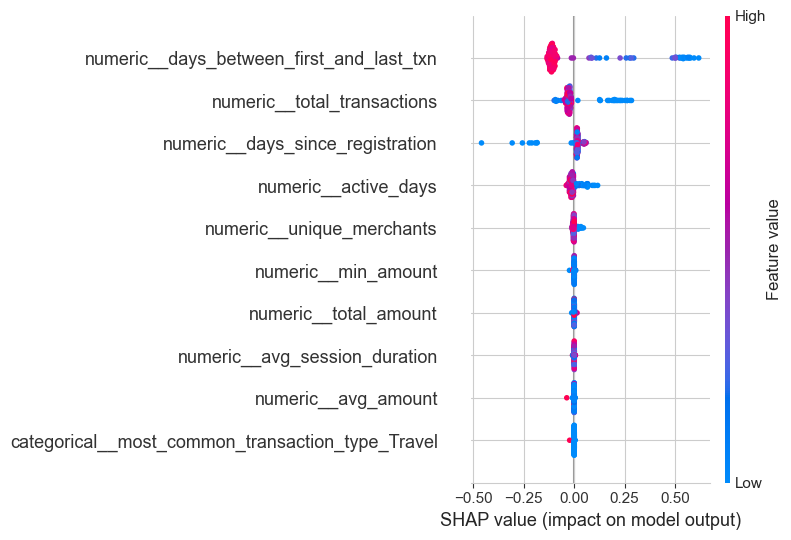

In [13]:

shap.summary_plot(shap_values.values, X_val_transformed[:200], feature_names=feature_names_out,
                   max_display=10, show=False)
plt.tight_layout()
plt.show()


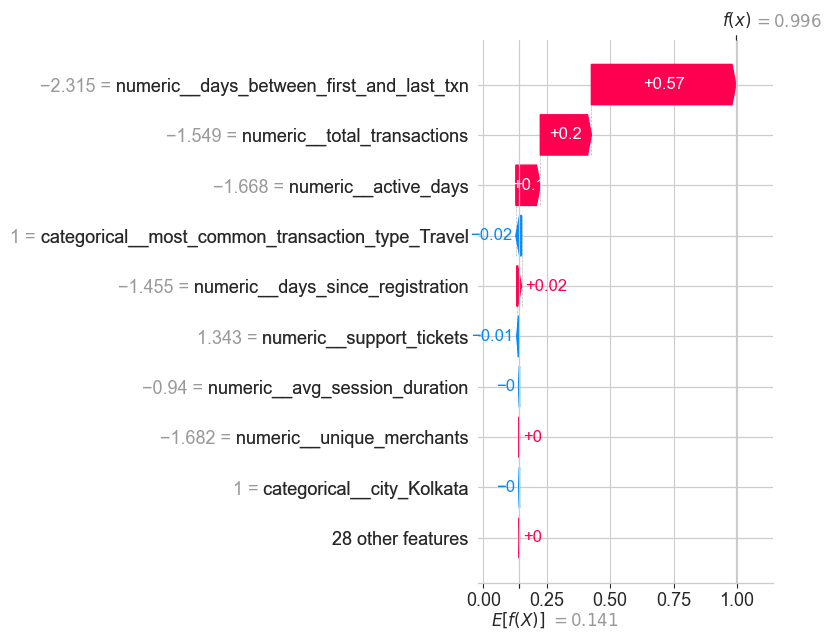

In [14]:

# Explain one specific churned user (within the first 200 rows we computed SHAP
# values for) -- this is the artifact you'd actually hand to a retention team
# ("here's exactly why we think this user will churn").
churned_positions = np.where(y_val_churn.values[:200] == 1)[0]
example_idx = churned_positions[0]

shap.plots.waterfall(shap_values[example_idx], max_display=10, show=False)
plt.tight_layout()
plt.show()


## 9. Business translation: expected value of a retention campaign

Turning model output into a business decision: rank users by calibrated churn probability, and estimate the expected value of running a retention campaign on the top-N risk segment, given an assumed offer cost and win-back rate. This is the kind of number that should ultimately justify the model's existence to stakeholders, not accuracy/AUC in isolation.

In [15]:

WIN_BACK_RATE = 0.30        # fraction of contacted at-risk users who are actually retained by the offer
AVG_USER_LTV = 120.0        # average retained lifetime value if churn is prevented
OFFER_COST = COST_FP

eval_df = X_val.copy()
eval_df["churn_probability"] = proba_cal
eval_df["actual_churn"] = y_val_churn.values
eval_df = eval_df.sort_values("churn_probability", ascending=False).reset_index(drop=True)

campaign_sizes = [50, 100, 200, 500, len(eval_df)]
rows = []
for n in campaign_sizes:
    targeted = eval_df.head(n)
    true_churners_targeted = targeted["actual_churn"].sum()
    expected_saved = true_churners_targeted * WIN_BACK_RATE
    expected_value = expected_saved * AVG_USER_LTV - n * OFFER_COST
    rows.append({"campaign_size": n, "true_churners_reached": int(true_churners_targeted),
                 "expected_users_saved": round(expected_saved, 1),
                 "expected_net_value": round(expected_value, 2)})

pd.DataFrame(rows)


,campaign_size,true_churners_reached,expected_users_saved,expected_net_value
0,50,50,15.0,1550.0
1,100,100,30.0,3100.0
2,200,200,60.0,6200.0
3,500,500,150.0,15500.0
4,92662,11766,3529.8,-39734.0


## 10. Save the calibrated pipeline as the final production artifact

Bundling the calibrated model + the cost-optimal threshold (not the earlier F1-optimal one from `src/models/train.py`) so the deployed service reflects this notebook's business-driven threshold, if the team decides to adopt it.

In [16]:

final_artifact = {
    "pipeline": calibrated_pipeline,
    "threshold": float(best_threshold),
    "feature_columns": list(X_train.columns),
    "notes": "Calibrated (isotonic) + cost-based threshold from notebook 04",
}
out_path = resolve_path(cfg["artifacts"]["pipeline_path"]).with_name("churn_pipeline_calibrated.joblib")
joblib.dump(final_artifact, out_path)
print("Saved:", out_path)


Saved: C:\Users\Abhishek\Documents\projects\New folder\churn_prediction_production\churn_prediction\saved_models\churn_pipeline_calibrated.joblib
